# Week 3 Mini Task

# Storytelling with Charts

## Stock Selected
Reliance Industries Ltd (RELIANCE.NS)

## Objective

This notebook tells a simple story about Reliance stock using three visualizations:

1. Price Trend
2. Returns Distribution
3. Rolling Volatility

The purpose is to understand stock performance, risk, and return behavior.

In [20]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
reliance = yf.download(
    "RELIANCE.NS",
    period="5y",
    auto_adjust=True
)

reliance.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-06-14,1016.755432,1022.801874,994.177443,1003.213203,20332436
2021-06-15,1019.065247,1030.342889,1014.671929,1024.047382,15174215
2021-06-16,1001.673218,1017.729157,999.068938,1016.755420,10797349
2021-06-17,1003.507507,1012.271500,987.315715,996.419342,15745975
2021-06-18,1008.036682,1012.271504,989.331180,1007.968755,29369026


In [22]:
if isinstance(reliance.columns, pd.MultiIndex):
    reliance.columns = reliance.columns.get_level_values(0)

In [23]:
reliance["Daily_Return"] = (
    reliance["Close"]
    .pct_change()
)

# Chart 1 — Price Trend

This chart shows how Reliance stock price has moved over time.

A rising trend generally indicates positive long-term performance.

Investors often use price trends to identify growth opportunities.

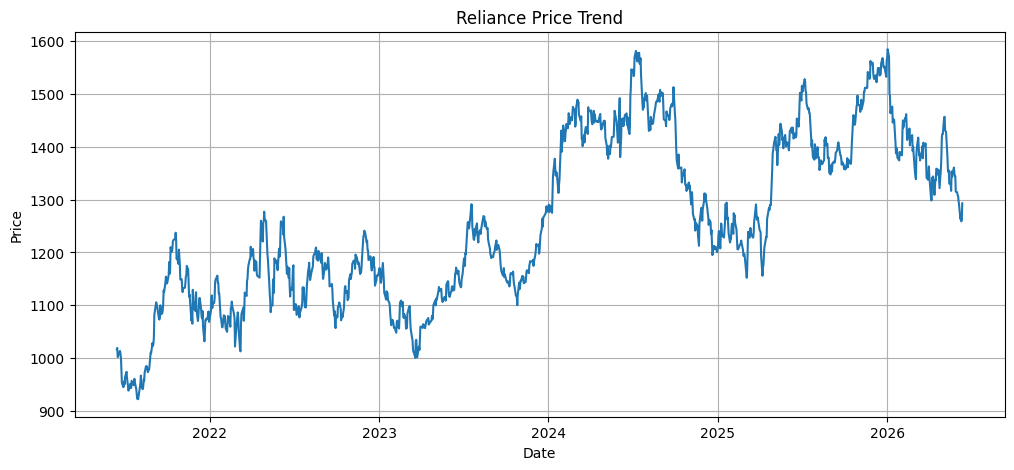

In [24]:
plt.figure(figsize=(12,5))

plt.plot(
    reliance.index,
    reliance["Close"]
)

plt.title("Reliance Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.savefig(
    "../week03/images/price_trend.png",
    dpi=150
)

plt.show() 

# Chart 2 — Returns Distribution

Daily returns measure percentage change in price from one day to the next.

Most returns are concentrated around small values, while large gains or losses occur less frequently.

This helps us understand return behavior and risk.

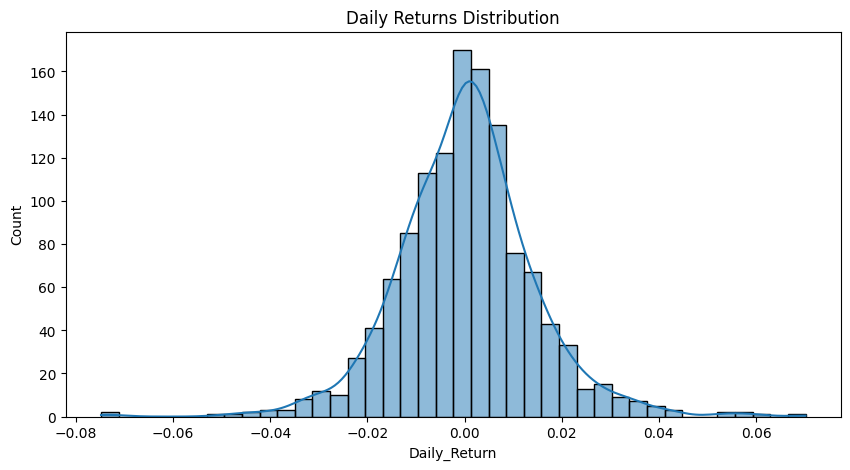

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    reliance["Daily_Return"].dropna(),
    bins=40,
    kde=True
)

plt.title("Daily Returns Distribution")

plt.savefig(
    "../week03/images/returns_distribution.png",
    dpi=150
)

plt.show()

# Chart 3 — Rolling Volatility

Volatility measures how much prices fluctuate.

Higher volatility means higher uncertainty and risk.

This chart uses a 30-day rolling standard deviation to track changing market risk over time.

In [26]:
reliance["Volatility"] = (
    reliance["Daily_Return"]
    .rolling(30)
    .std()
)

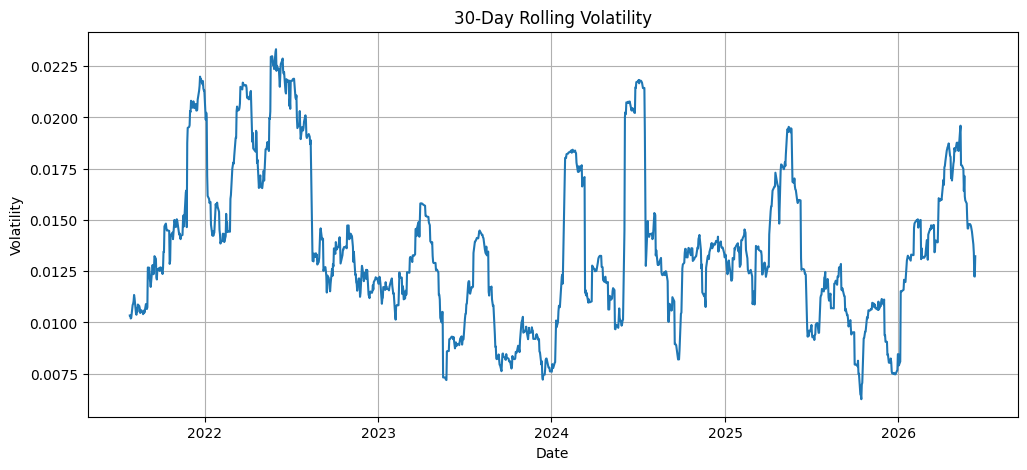

In [27]:
plt.figure(figsize=(12,5))

plt.plot(
    reliance.index,
    reliance["Volatility"]
)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)

plt.savefig(
    "../week03/images/rolling_volatility.png",
    dpi=150
)

plt.show()

# Final Observation

Based on the charts:

1. Reliance has shown a generally positive long-term price trend.
2. Daily returns are concentrated around small values, with occasional extreme movements.
3. Volatility changes over time, indicating periods of higher and lower market risk.

Overall, Reliance demonstrates long-term growth with moderate fluctuations in daily returns.